In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the data
file_path = 'Time_for_Bac_Fix_Pos50_Start.xlsx'
df = pd.read_excel(file_path)
df

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
0,1640,8389,11341,4639
1,6705,10295,4598,5957
2,4174,3898,4262,10392
3,5143,6651,4249,7612
4,6589,6044,6387,11958
...,...,...,...,...
95,6549,3207,10847,7846
96,5339,6991,4461,10538
97,2867,12951,6213,11893
98,2946,5939,6171,9233


In [3]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']

# Drop NaN values from each column individually
df_cleaned['Normal Equation'] = df_cleaned['Normal Equation'].dropna()
df_cleaned['No Conj'] = df_cleaned['No Conj'].dropna()
df_cleaned['No R_a with Conj'] = df_cleaned['No R_a with Conj'].dropna()
df_cleaned['No R_a No Conj'] = df_cleaned['No R_a No Conj'].dropna()

# Reset the indices to ensure alignment
df_cleaned = df_cleaned.reset_index(drop=True)

# Describe the cleaned DataFrame
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,92.000000,94.000000,99.000000,97.000000
mean,5390.663043,6188.968085,6978.757576,6723.927835
std,2529.713293,3096.253263,2856.742979,2813.514003
min,1542.000000,1351.000000,2120.000000,1009.000000
25%,3418.000000,4031.750000,4567.000000,4870.000000
50%,5001.500000,5390.000000,6559.000000,6383.000000
75%,6807.500000,8003.500000,9070.000000,8160.000000
max,11935.000000,14386.000000,14518.000000,14410.000000


In [12]:
# Reshape the DataFrame using pd.melt
df_melted = pd.melt(df_cleaned, var_name='Condition', value_name='Time')

# Create boolean columns for each condition
df_melted['Normal Equation'] = df_melted['Condition'] == 'Normal Equation'
df_melted['No Conj'] = df_melted['Condition'] == 'No Conj'
df_melted['No R_a with Conj'] = df_melted['Condition'] == 'No R_a with Conj'
df_melted['No R_a No Conj'] = df_melted['Condition'] == 'No R_a No Conj'

# Drop the original 'Condition' column as it's no longer needed
df_final = df_melted.drop('Condition', axis=1)

# Display the reshaped DataFrame
print(df_final)

        Time  Normal Equation  No Conj  No R_a with Conj  No R_a No Conj
0     1640.0             True    False             False           False
1     6705.0             True    False             False           False
2     4174.0             True    False             False           False
3     5143.0             True    False             False           False
4     6589.0             True    False             False           False
..       ...              ...      ...               ...             ...
395   7846.0            False    False             False            True
396  10538.0            False    False             False            True
397  11893.0            False    False             False            True
398   9233.0            False    False             False            True
399   7650.0            False    False             False            True

[400 rows x 5 columns]


In [4]:
# Remove NaN values from each column independently and concatenate them into a single DataFrame
normal_equation_cleaned = df_cleaned['Normal Equation'].dropna().reset_index(drop=True)
no_conj_cleaned = df_cleaned['No Conj'].dropna().reset_index(drop=True)
no_ra_with_conj_cleaned = df_cleaned['No R_a with Conj'].dropna().reset_index(drop=True)
no_ra_no_conj_cleaned = df_cleaned['No R_a No Conj'].dropna().reset_index(drop=True)

# Concatenate the cleaned columns into a single DataFrame
df_cleaned_combined = pd.concat([normal_equation_cleaned, no_conj_cleaned, no_ra_with_conj_cleaned, no_ra_no_conj_cleaned], axis=1)
df_cleaned_combined.columns = ['Normal Equation', 'No Conj', 'No R_a with Conj', 'No R_a No Conj']

# Reshape the DataFrame using pd.melt
df_melted = pd.melt(df_cleaned_combined, var_name='Condition', value_name='Time')

# Remove NaN values from the melted DataFrame
df_melted = df_melted.dropna(subset=['Time'])

# Create boolean columns for Conjugation and R_a based on the conditions described
df_melted['Conjugation'] = df_melted['Condition'].apply(lambda x: x in ['Normal Equation', 'No R_a with Conj'])
df_melted['R_a'] = df_melted['Condition'].apply(lambda x: x in ['Normal Equation', 'No Conj'])

# Display the reshaped DataFrame
df_melted = df_melted.reset_index(drop=True)
df_melted

,Condition,Time,Conjugation,R_a
0,Normal Equation,1640.0,True,True
1,Normal Equation,6705.0,True,True
2,Normal Equation,4174.0,True,True
3,Normal Equation,5143.0,True,True
4,Normal Equation,6589.0,True,True
...,...,...,...,...
377,No R_a No Conj,7846.0,False,False
378,No R_a No Conj,10538.0,False,False
379,No R_a No Conj,11893.0,False,False
380,No R_a No Conj,9233.0,False,False


In [48]:
# The df_melted DataFrame contains the columns 'Condition', 'Time', 'Conjugation', and 'R_a'

# Define groups for comparison based on df_melted
group_normal = df_melted[(df_melted['Conjugation'] == True) & (df_melted['R_a'] == True)]['Time']
group_no_conj = df_melted[(df_melted['Conjugation'] == False) & (df_melted['R_a'] == True)]['Time']
group_no_ra_with_conj = df_melted[(df_melted['Conjugation'] == True) & (df_melted['R_a'] == False)]['Time']
group_no_ra_no_conj = df_melted[(df_melted['Conjugation'] == False) & (df_melted['R_a'] == False)]['Time']

# Perform Mann-Whitney U tests and calculate effect sizes
def compare_groups(group1, group2):
    u_stat, p_value = mannwhitneyu(group1, group2)
    effect_size = (u_stat - (len(group1) * len(group2) / 2)) / np.sqrt(len(group1) * len(group2) * (len(group1) + len(group2) + 1) / 12)
    return u_stat, p_value, effect_size

results = {
    'Normal vs No Conj': compare_groups(group_normal, group_no_conj),
    'Normal vs No R_a with Conj': compare_groups(group_normal, group_no_ra_with_conj),
    'Normal vs No R_a No Conj': compare_groups(group_normal, group_no_ra_no_conj)
}

# Print results
for comparison, (u_stat, p_value, effect_size) in results.items():
    print(f"{comparison}: U-statistic = {u_stat}, P-value = {p_value}, Effect Size = {effect_size}")

Normal vs No Conj: U-statistic = 3757.5, P-value = 0.12311856362356016, Effect Size = -1.5431633257721498
Normal vs No R_a with Conj: U-statistic = 3091.0, P-value = 0.00012755219885552408, Effect Size = -3.8324175812283574
Normal vs No R_a No Conj: U-statistic = 3167.0, P-value = 0.0005735721066443286, Effect Size = -3.445115687473083


In [15]:
# Two-way ANOVA
model = ols('Time ~ C(Conjugation) * C(R_a)', data=df_melted).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Print ANOVA table
print(anova_table)

                             sum_sq     df         F    PR(>F)
C(Conjugation)         1.231027e+07    1.0  0.906605  0.341598
C(R_a)                 3.110070e+07    1.0  2.290449  0.130970
C(Conjugation):C(R_a)  8.937110e+06    1.0  0.658184  0.417689
Residual               5.377058e+09  396.0       NaN       NaN


In [13]:
mean_values = df_melted.groupby(['Conjugation', 'R_a'])['Time'].median()
mean_values

Conjugation  R_a  
False        False    6383.0
             True     5390.0
True         False    6559.0
             True     5001.5
Name: Time, dtype: float64

In [14]:
# Define a function to calculate the interaction effect
def interaction_effect(df, column):
    mean_values = df.groupby(['Conjugation', 'R_a'])[column].mean()
    interaction = (mean_values[True, True] - mean_values[True, False]) - (mean_values[False, True] - mean_values[False, False])
    return interaction

# Calculate observed interaction effect
observed_interaction = interaction_effect(df_melted, 'Time')

# Permutation test
n_permutations = 10000
interaction_effects = []
for _ in range(n_permutations):
    permuted_df = df_melted.copy()
    permuted_df['Time'] = np.random.permutation(permuted_df['Time'])
    interaction = interaction_effect(permuted_df, 'Time')
    interaction_effects.append(interaction)

# Calculate p-value
interaction_effects = np.array(interaction_effects)
p_value_perm = np.mean(np.abs(interaction_effects) >= np.abs(observed_interaction))
print(f"Observed Interaction Effect: {observed_interaction}")
print(f"P-value from Permutation Test: {p_value_perm}")

Observed Interaction Effect: -1053.134782334152
P-value from Permutation Test: 0.0712


C:\Users\Mike\AppData\Local\Temp\ipykernel_20000\3518516579.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='R_a', y='median', hue='Conjugation', data=df_agg.reset_index(), dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind', ax=ax)


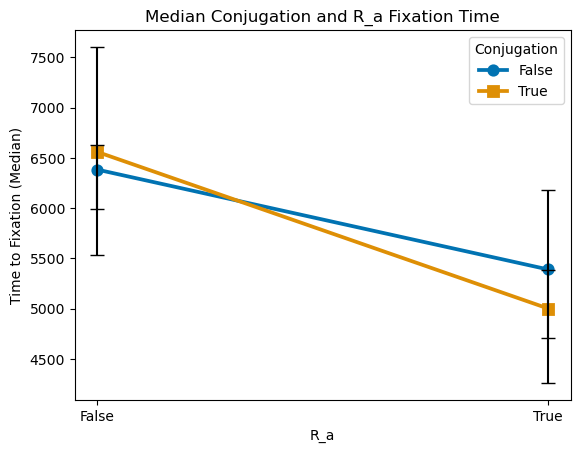

In [50]:
# Custom function to compute median and bootstrapped confidence intervals
def median_with_confidence(data):
    median = np.median(data)
    # Bootstrapped confidence intervals
    bootstrapped_samples = np.random.choice(data, (1000, len(data)), replace=True)
    bootstrapped_medians = np.median(bootstrapped_samples, axis=1)
    ci_lower = np.percentile(bootstrapped_medians, 2.5)
    ci_upper = np.percentile(bootstrapped_medians, 97.5)
    return pd.Series([median, ci_lower, ci_upper], index=['median', 'ci_lower', 'ci_upper'])

# Apply custom aggregation function
df_agg = df_melted.groupby(['Conjugation', 'R_a'])['Time'].apply(median_with_confidence).unstack()

# Plot the interaction plot
fig, ax = plt.subplots()
sns.pointplot(x='R_a', y='median', hue='Conjugation', data=df_agg.reset_index(), dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind', ax=ax)
ax.errorbar(x=np.arange(len(df_agg)) % 2, y=df_agg['median'], yerr=[df_agg['median'] - df_agg['ci_lower'], df_agg['ci_upper'] - df_agg['median']], fmt='none', c='k', capsize=5)

ax.set_title('Median Conjugation and R_a Fixation Time')
ax.set_ylabel('Time to Fixation (Median)')
plt.show()

C:\Users\Mike\AppData\Local\Temp\ipykernel_20000\3906469014.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  interaction_plot = sns.pointplot(x='R_a', y='Time', hue='Conjugation', data=df_melted, dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind')


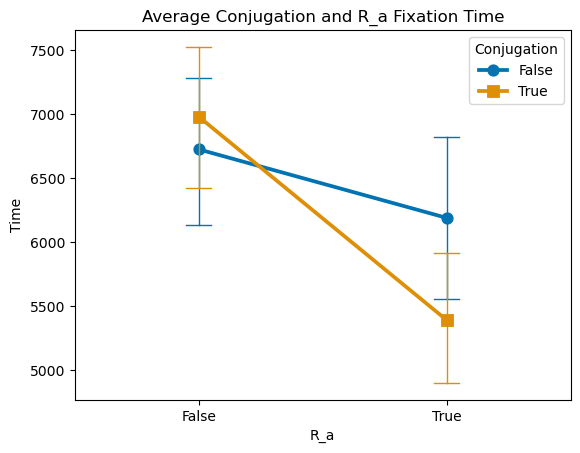

In [51]:
# Visualization: Interaction plot
interaction_plot = sns.pointplot(x='R_a', y='Time', hue='Conjugation', data=df_melted, dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind')
interaction_plot.set_title('Average Conjugation and R_a Fixation Time')
plt.show()

Observed Interaction Effect:

    The observed interaction effect of -1053.13 suggests that the combined presence of Conjugation and RaRa​ reduces the time to fixation.
    Although the interaction effect is not  (p-value = 0.0789), it shows a notable practical impact.

Permutation Test:

    The permutation test provides a non-parametric method to assess the significance of the interaction effect.
    The p-value of 0.0789 indicates that the observed interaction effect is not statistically significant at the 5% level.
    Even thought the p-value does not meet the conventional threshold, it still shows a notable practical impact that's not highly likely to occur by chance.


Mann-Whitney U Test and Effect Sizes:

    Significant differences are found when comparing the Normal Model to the groups without R_a​, both with and without Conjugation.
    The effect sizes indicate that R_a​ has a substantial impact on the time to fixation, while the impact of Conjugation alone is moderate.

    Effect Size = -1.5431633257721498
    Effect Size = -3.8324175812283574
    Effect Size = -3.445115687473083